In [1]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

from pathlib import Path
analy_script_path = Path.cwd().parent.parent.parent / 'analysis'
if str(analy_script_path) not in sys.path:
    sys.path.append(str(analy_script_path))

import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable
import cvxpy as cp
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc
import post_anal as pa



from aquarel import load_theme
theme_notused = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme = (
        load_theme("scientific")
        .set_font(family="serif", serif=["cmr10"]) # useless since text.usetex is set to True
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="xx-large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
            "axes.formatter.use_mathtext": "True",
            'mathtext.fontset':'cm',
            "text.usetex":"True"
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20
solo_fontsize = 16


plot_dir = "/home/sam/thesis/writingII/images/"

In [2]:
eos_se, mr_se = pa.load_eos_data('SE_10ns_1')

In [3]:
randints = np.random.randint(0, 20000, size=5)
randints = [16666,12345,15469,4282,569]

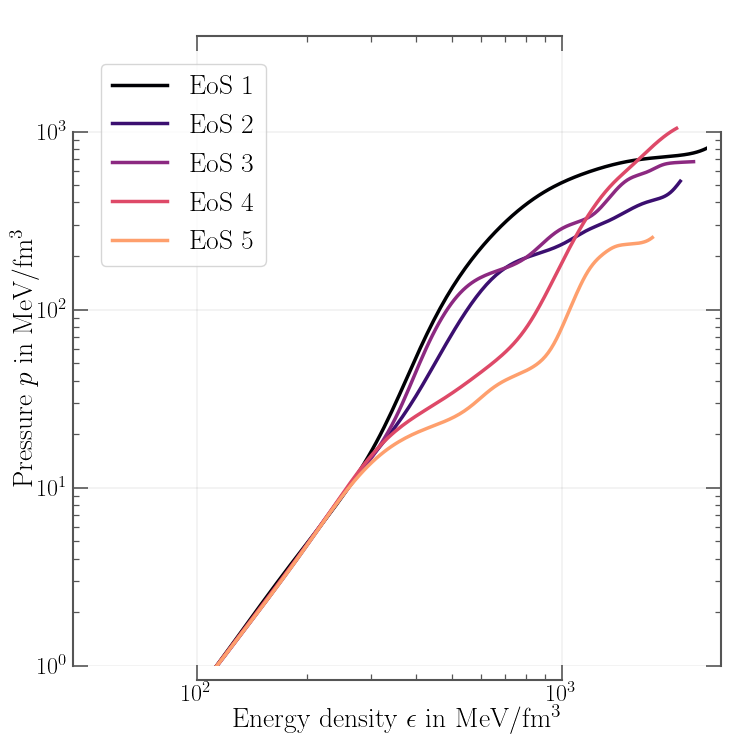

In [4]:
colours = cm.magma(np.linspace(0, 0.8, len(randints)))
c = 0
plt.figure(figsize=(8, 8))
for idx in randints:
    c = c + 1
    plt.plot(eos_se[0][idx], eos_se[1][idx], color=colours[c-1], label=f"EoS {c}", alpha=1, linewidth=2.5)
plt.xlabel('Energy density $\epsilon$ in MeV/fm$^3$', fontsize=big_fontsize)
plt.ylabel('Pressure $p$ in MeV/fm$^3$', fontsize=big_fontsize)
plt.yscale('log')
plt.xscale('log')
plt.xlim(left=25)
plt.ylim(bottom=1)
plt.title(' ', fontsize=big_fontsize)
plt.legend(loc='upper left', fontsize=big_fontsize)
plt.xlim(5e1, 2.5e3)
theme.apply_transforms()
plt.savefig(plot_dir + "eos_eg.png", dpi=300)

plt.show()

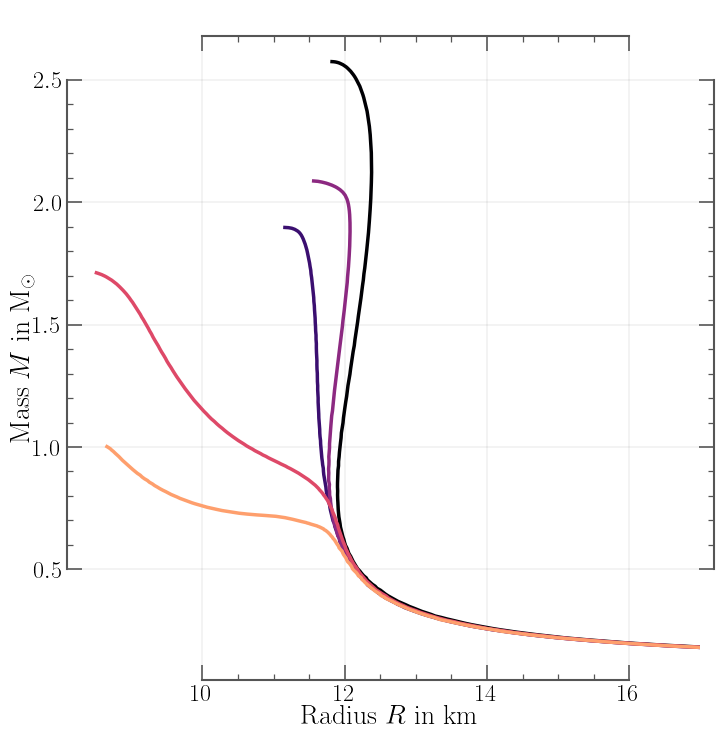

In [5]:
c = 0
plt.figure(figsize=(8, 8))
for idx in randints:
    c = c + 1
    plt.plot(mr_se[0][idx], mr_se[1][idx], color=colours[c-1], label=f"MR {c}", alpha=1, linewidth=2.5)
plt.ylabel('Mass $M$ in M$_\odot$', fontsize=big_fontsize)
plt.xlabel('Radius $R$ in km', fontsize=big_fontsize)
plt.xlim(right=17)
plt.title(' ', fontsize=big_fontsize)
theme.apply_transforms()
plt.savefig(plot_dir + "mr_eg.png", dpi=300)
plt.show()

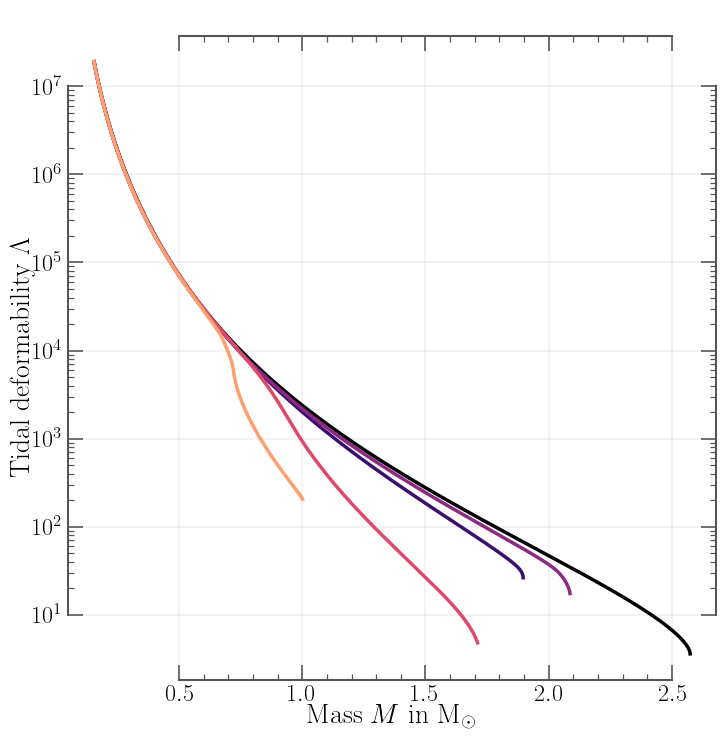

In [6]:
c = 0
plt.figure(figsize=(8, 8))
for idx in randints:
    plt.plot(mr_se[1][idx], mr_se[2][idx], color=colours[c], alpha=1, linewidth=2.5)
    c+=1
plt.xlabel('Mass $M$ in M$_\odot$', fontsize=big_fontsize)
plt.ylabel('Tidal deformability $\Lambda$', fontsize=big_fontsize)
plt.yscale('log')
plt.title(' ', fontsize=big_fontsize)
theme.apply_transforms()
plt.savefig(plot_dir + "mt_eg.png", dpi=300)
plt.show()